In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import czifile
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import sys
# from umap import UMAP
import joblib
import pandas as pd

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE




In [3]:
ae = torch.load('/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323/ae_model_ep9999.pt', map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024

In [4]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
# read in the prediction
pax_MSE_df = pd.read_csv(os.path.join(root_dir,"pax_MSE_df.csv"))

In [21]:
pax_MSE_df.columns

Index(['Unnamed: 0', 'Unnamed: 0_x', 'ctrl_y_str', 'crop_img_filename',
       'group_labels', 'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge_x', 'front_flag_x', 'Unnamed: 0.1', 'Unnamed: 0_y',
       'y_corner4', 'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3',
       'rand_ty', 'x_corner1', 'x_corner3', 'movie_partitioned_data_dir',
       'y_corner2', 'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir',
       'image_folder', 'rand_tx', 'filename', 'y_c', 'y_corner1',
       'dist_cell_edge_y', 'front_flag_y', 'group', 'unique_ID', 'AE_MSE'],
      dtype='object')

In [22]:
patch_label_df = pd.read_csv(os.path.join(root_dir,"patch_label_df_FAclass_position_joint_GB_pred.csv"))

In [23]:
patch_label_df.columns


Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0',
       'ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred'],
      dtype='object')

In [24]:
def pick_latent_columns(df: pd.DataFrame, latent_cols: list[str] | None, latent_prefix: str | None) -> list[str]:
    if latent_cols:
        missing = [c for c in latent_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing latent columns in CSV: {missing}")
        return latent_cols

    if latent_prefix:
        cols = [c for c in df.columns if c.startswith(latent_prefix)]
        if len(cols) != 8:
            raise ValueError(f"Found {len(cols)} columns with prefix '{latent_prefix}', expected 8: {cols}")
        return cols

    # fallback: auto-pick first 8 numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) < 8:
        raise ValueError(
            f"Need at least 8 numeric columns for latents. Found {len(numeric_cols)} numeric columns: {numeric_cols}"
        )
    return numeric_cols[:8]

In [26]:
latent_cols = pick_latent_columns(patch_label_df, latent_cols=[],latent_prefix='lat')
X = patch_label_df[latent_cols].to_numpy(dtype=float)

In [29]:
latent_cols

['lat_d0',
 'lat_d1',
 'lat_d2',
 'lat_d3',
 'lat_d4',
 'lat_d5',
 'lat_d6',
 'lat_d7']

In [28]:
X.shape

(23656, 8)

In [30]:
import phate

In [39]:
# PHATE estimator + embedding
phate_op = phate.PHATE(
    n_components=2,
    knn=5,
    decay=5,
    random_state=0,
)
Y = phate_op.fit_transform(X)

Calculating PHATE...
  Running PHATE on 23656 observations and 8 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 1.13 seconds.
    Calculating affinities...
    Calculated affinities in 4.39 seconds.
  Calculated graph and diffusion operator in 5.68 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 4.59 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.91 seconds.
  Calculated landmark operator in 6.51 seconds.
  Calculating optimal t...
    Automatically selected t = 14
  Calculated optimal t in 0.95 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.46 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 1.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.54 seconds.
Calculated PHATE in 15.90 seconds.


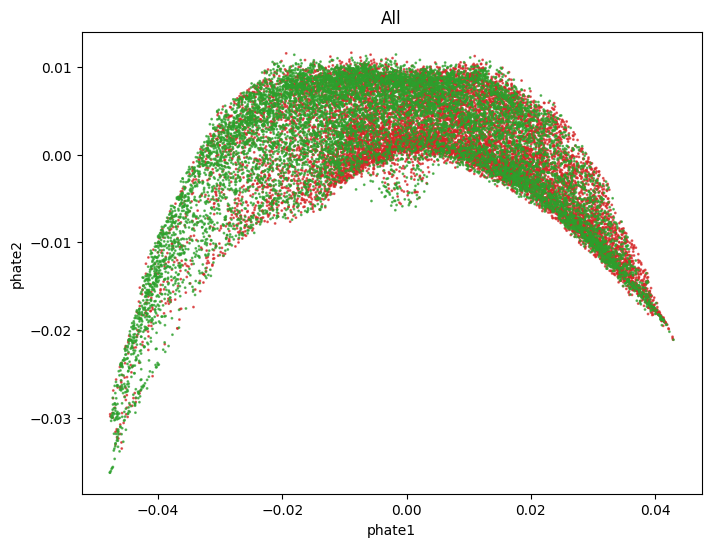

In [76]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = patch_label_df['front_flag'] >-1
filtered_latents = Y[mask]
filtered_colors = 3- patch_label_df['group_labels'][mask]  +0.5

fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

# cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
# cbar.ax.set_ylim(2,4)
# plt.xlim(-2.5,10.5)
# plt.ylim(0.5,7.5)

plt.xlabel("phate1")
plt.ylabel("phate2")
plt.title("All")

plt.show()


In [5]:
czi_base = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568'

In [6]:
analysis_base = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/'

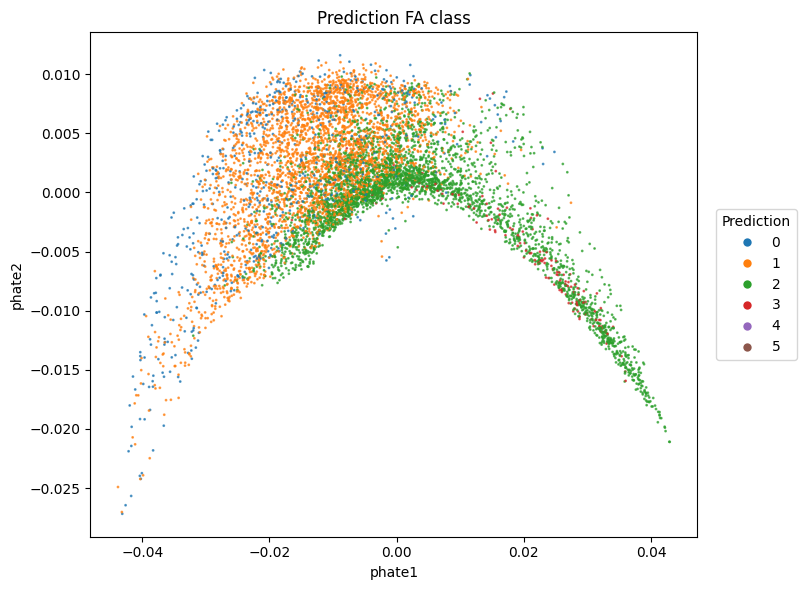

In [78]:
# plot the predictions with Gradient Boosting Classifier
y_FA_class_all_pred = patch_label_df['FA_class_based_pred']
mask = y_FA_class_all_pred !=4

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [classification_labelID_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    Y[mask,0],
    Y[mask,1],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("phate1")
plt.ylabel("phate2")
plt.title("Prediction FA class")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_labelID_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_labelID_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [43]:
recon_dir = os.path.join(analysis_base, 'recon_full_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(recon_dir, exist_ok=True)

recon_visual_dir = os.path.join(analysis_base, 'recon_visual_full_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(recon_visual_dir, exist_ok=True)

raw_visual_dir = os.path.join(analysis_base, 'raw_visual_full_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(raw_visual_dir, exist_ok=True)

raw_grid_dir = os.path.join(analysis_base, 'raw_full_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(raw_grid_dir, exist_ok=True)

raw_patch_dir = os.path.join(analysis_base, 'raw_patch_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(raw_patch_dir, exist_ok=True)

recon_patch_dir = os.path.join(analysis_base, 'recon_patch_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(recon_patch_dir, exist_ok=True)




In [44]:
csv_folder = analysis_base + 'ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1159'
csv_filename = 'data_prep_record_9_t9.csv'
group_labels = 0
ctrl_y_str = 'ctrl'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base+ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"

model_min = 0
model_max = 52300
# newdata_min = 9
# newdata_max = 28700
newdata_min = 0
newdata_max = 52300

In [9]:
gb = joblib.load("../results/pax_AE_lat8_FA_gb_classifier.joblib")
gb_position = joblib.load("../results/pax_AE_lat8_position_gb_classifier.joblib")



In [10]:
tab10_colors = [
    "#1f77b4",  # 0 - blue
    "#ff7f0e",  # 1 - orange
    "#2ca02c",  # 2 - green
    "#d62728",  # 3 - red
    "#9467bd",  # 4 - purple
    "#8c564b",  # 5 - brown
    "#e377c2",  # 6 - pink
    "#7f7f7f",  # 7 - gray
    "#bcbd22",  # 8 - olive
    "#17becf",  # 9 - cyan
]

In [11]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]

classification_labelID_to_color = {
    i: tab10_colors[i]
    for i, cls in enumerate(classification_label_order)
}

In [12]:
position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]
position_labelID_to_color = {
    i: tab10_colors[i]
    for i, cls in enumerate(position_label_order)
}

In [13]:
classification_labelID_to_color

{0: '#1f77b4',
 1: '#ff7f0e',
 2: '#2ca02c',
 3: '#d62728',
 4: '#9467bd',
 5: '#8c564b'}

In [60]:
pad_size = 64

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))
all_image_csv["org_recon_mse"] = np.nan  # new column to fill

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']
                
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)

        ae = ae.to(device)
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)
        

        mse_val = torch.mean((recon_image.squeeze() - tensor_patch) ** 2).item()
        all_image_csv.loc[index, "org_recon_mse"] = mse_val

    #     latent_np = latent.detach().cpu().numpy()    # shape (1, 8)
    #     y_pred = gb.predict(latent_np)[0]            # scalar label
        
    #     latent_array.append(latent)        

    #     recon_patch_filename = 'fa'+str(int(y_pred)).zfill(3) +"_recon_patch_"+patch_name+'.tif'
    
    #     tiff.imwrite(
    #         os.path.join(recon_patch_dir,recon_patch_filename),
    #         recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
    #         imagej=True,              # Write ImageJ metadata block
    #         metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    #     )    
        
    #     raw_patch_img_filename = 'fa'+str(int(y_pred)).zfill(3) +"_raw_patch_"+patch_name+'.tif'
        
    #     tiff.imwrite(
    #         os.path.join(raw_patch_dir,raw_patch_img_filename),
    #         normed_raw_patch.astype(np.float32),
    #         imagej=True,              # Write ImageJ metadata block
    #         metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    #     )

    #     raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
    #     recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        
    # recon_img_filename = "recon_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(recon_dir,recon_img_filename),
    #     recon_whole_image.astype(np.float32),#.swapaxes(0,2),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )    
    
    # raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(raw_grid_dir,raw_grid_img_filename),
    #     raw_whole_image.astype(np.float32),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )

    # fig, ax = plt.subplots(1,2, figsize=(8,4))
    # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax[0].set_title('FA class: Raw - '+ filename[-14:-4])
    # ax[0].axis('off')
    # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)
    # ax[1].set_title('Recon - '+ filename[-14:-4])
    # ax[1].axis('off')
    # fig.savefig(os.path.join(recon_visual_dir,recon_img_filename), dpi=300)
    



    # fig1, ax1 = plt.subplots(1,2, figsize=(8,4))
    # ax1[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax1[0].set_title('Position: Raw - '+ filename[-14:-4])
    # ax1[0].axis('off')
    # ax1[1].imshow(recon_whole_image,cmap=plt.cm.gray)
    # ax1[1].set_title('Recon - '+ filename[-14:-4])
    # ax1[1].axis('off')
    
    
    # this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # linewidth=0.6
    # for index, row in this_file_csv.iterrows():       
    #     index_count = index_count+1 
    #     x_corner1 = int(row["x_corner1"])- pad_size + linewidth 
    #     x_corner3 = int(row["x_corner3"])- pad_size -linewidth
    #     y_corner1 = int(row["y_corner1"])- pad_size +linewidth
    #     y_corner3 = int(row["y_corner3"])- pad_size -linewidth
    #     patch_name = row['crop_img_filename']
                
    #     raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
    #     normed_raw_patch = raw_patch.copy() * 240 
    #     normed_raw_patch[normed_raw_patch > 254] = 254
    #     normed_raw_patch = normed_raw_patch/255
        
    #     tensor_patch = torch.from_numpy(normed_raw_patch)
    #     tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
    #     tensor_patch = tensor_patch.to(device)

    #     ae = ae.to(device)
    #     with torch.no_grad():
    #         recon_image, latent = ae(tensor_patch)
    #     latent_np = latent.detach().cpu().numpy()    # shape (1, 8)
    #     y_pred = gb.predict(latent_np)[0]            # scalar label
    #     position_pred = gb_position.predict(latent_np)[0]            # scalar label
                
    #     ax[0].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #                [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = classification_labelID_to_color[y_pred],\
    #             linewidth=linewidth, alpha=0.8)
        
    #     ax[1].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #         [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = classification_labelID_to_color[y_pred],\
    #             linewidth=linewidth, alpha=0.8)
        

    #     ax1[0].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #                [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = position_labelID_to_color[position_pred],\
    #             linewidth=linewidth, alpha=0.8)
        
    #     ax1[1].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #         [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = position_labelID_to_color[position_pred],\
    #             linewidth=linewidth, alpha=0.8)
        
    # recon_img_filename = "fa_class_pred_recon_"+filename+'.tif'
    # fig.savefig(os.path.join(recon_visual_dir,recon_img_filename), dpi=300)
    
    # recon_img_filename = "position_pred_recon_"+filename+'.tif'
    # fig1.savefig(os.path.join(recon_visual_dir,recon_img_filename), dpi=300)
    
    # break

{'whiskers': [<matplotlib.lines.Line2D at 0x7f400f8e0e80>,
 'caps': [<matplotlib.lines.Line2D at 0x7f400f8e13c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f400f8e0be0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f400f8e17e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f400f8e1a80>],
 'means': []}

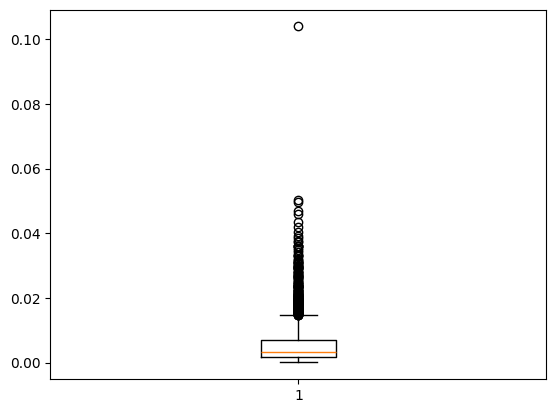

In [47]:
plt.boxplot(all_image_csv['recon_mse'])

In [16]:
model_min = 0
model_max = 52300
newdata_min = 9
newdata_max = 28700

In [48]:
recon_dir = os.path.join(analysis_base, 'range_recon_full_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(recon_dir, exist_ok=True)

recon_visual_dir = os.path.join(analysis_base, 'range_recon_visual_full_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(recon_visual_dir, exist_ok=True)

recon_patch_dir = os.path.join(analysis_base, 'range_recon_patch_pax_ch1_ps32_lat8_20251203_2323')
os.makedirs(recon_patch_dir, exist_ok=True)




In [74]:
pad_size = 64

# all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))
all_image_csv["range_recon_mse"] = np.nan  # new column to fill
all_image_csv["reverted_range_recon_mse"] = np.nan  # new column to fill
all_image_csv["range_mean"] = np.nan  # new column to fill
all_image_csv["raw_mean"] = np.nan  # new column to fill
all_image_csv["range_recon_mse_normalized"] = np.nan  # new column to fill
all_image_csv["reverted_range_recon_mse_normalized"] = np.nan  # new column to fill

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']
                
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        
        normed_01_raw_patch = (raw_patch.copy()*65535 - newdata_min)/(newdata_max-newdata_min)
        matched_raw_patch = (normed_01_raw_patch.copy()*(model_max-model_min) + model_min)/65535
        normed_raw_patch = matched_raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)

        ae = ae.to(device)
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)

        tensor_patch = tensor_patch.float()

        # 确保 recon 和 input 形状一致（通常 ae 输出就是 (1,1,H,W)）
        recon_image = recon_image.float()

        mse_val = F.mse_loss(recon_image, tensor_patch).detach().cpu().item()
        all_image_csv.loc[index, "range_recon_mse"] = mse_val
        all_image_csv.loc[index, "raw_mean"] = np.mean(raw_patch)
        den = float(torch.mean(tensor_patch).detach().cpu().item())
        all_image_csv.loc[index, "ranch_mean"] = den
        all_image_csv.loc[index, "range_recon_mse_normalized"] = float(mse_val) / (den + 1e-12)

        # all_image_csv.loc[index, "range_recon_mse_normalized"] =mse_val/torch.mean(tensor_patch)

        
    #     latent_np = latent.detach().cpu().numpy()    # shape (1, 8)
    #     y_pred = gb.predict(latent_np)[0]            # scalar label
        
    #     latent_array.append(latent)        

    #     recon_patch_filename = 'fa'+str(int(y_pred)).zfill(3) +"_recon_patch_"+patch_name+'.tif'
    
    #     tiff.imwrite(
    #         os.path.join(recon_patch_dir,recon_patch_filename),
    #         recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
    #         imagej=True,              # Write ImageJ metadata block
    #         metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    #     )    
        
    #     raw_patch_img_filename = 'fa'+str(int(y_pred)).zfill(3) +"_raw_patch_"+patch_name+'.tif'
        
    #     tiff.imwrite(
    #         os.path.join(raw_patch_dir,raw_patch_img_filename),
    #         normed_raw_patch.astype(np.float32),
    #         imagej=True,              # Write ImageJ metadata block
    #         metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    #     )

    #     raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
    #     recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        
    # recon_img_filename = "recon_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(recon_dir,recon_img_filename),
    #     recon_whole_image.astype(np.float32),#.swapaxes(0,2),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )    
    
    # raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(raw_grid_dir,raw_grid_img_filename),
    #     raw_whole_image.astype(np.float32),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )

    # fig, ax = plt.subplots(1,2, figsize=(8,4))
    # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax[0].set_title('FA class: Raw - '+ filename[-14:-4])
    # ax[0].axis('off')
    # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)
    # ax[1].set_title('Recon - '+ filename[-14:-4])
    # ax[1].axis('off')
    # fig.savefig(os.path.join(recon_visual_dir,recon_img_filename), dpi=300)
    



    # fig1, ax1 = plt.subplots(1,2, figsize=(8,4))
    # ax1[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax1[0].set_title('Position: Raw - '+ filename[-14:-4])
    # ax1[0].axis('off')
    # ax1[1].imshow(recon_whole_image,cmap=plt.cm.gray)
    # ax1[1].set_title('Recon - '+ filename[-14:-4])
    # ax1[1].axis('off')
    
    
    # this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # linewidth=0.6
    # for index, row in this_file_csv.iterrows():       
    #     index_count = index_count+1 
    #     x_corner1 = int(row["x_corner1"])- pad_size + linewidth 
    #     x_corner3 = int(row["x_corner3"])- pad_size -linewidth
    #     y_corner1 = int(row["y_corner1"])- pad_size +linewidth
    #     y_corner3 = int(row["y_corner3"])- pad_size -linewidth
    #     patch_name = row['crop_img_filename']
                
    #     raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
    #     normed_01_raw_patch = (raw_patch.copy()*65535 - newdata_min)/(newdata_max-newdata_min)
    #     matched_raw_patch = (normed_01_raw_patch.copy()*(model_max-model_min) + model_min)/65535
    #     normed_raw_patch = matched_raw_patch.copy() * 240 
    #     normed_raw_patch[normed_raw_patch > 254] = 254
    #     normed_raw_patch = normed_raw_patch/255
        
    #     tensor_patch = torch.from_numpy(normed_raw_patch)
    #     tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
    #     tensor_patch = tensor_patch.to(device)

    #     ae = ae.to(device)
    #     with torch.no_grad():
    #         recon_image, latent = ae(tensor_patch)
    #     latent_np = latent.detach().cpu().numpy()    # shape (1, 8)
    #     y_pred = gb.predict(latent_np)[0]            # scalar label
    #     position_pred = gb_position.predict(latent_np)[0]            # scalar label
                
    #     ax[0].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #                [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = classification_labelID_to_color[y_pred],\
    #             linewidth=linewidth, alpha=0.8)
        
    #     ax[1].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #         [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = classification_labelID_to_color[y_pred],\
    #             linewidth=linewidth, alpha=0.8)
        

    #     ax1[0].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #                [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = position_labelID_to_color[position_pred],\
    #             linewidth=linewidth, alpha=0.8)
        
    #     ax1[1].plot([x_corner1,x_corner1,x_corner3,x_corner3,x_corner1],\
    #         [y_corner1,y_corner3,y_corner3,y_corner1,y_corner1], \
    #             color = position_labelID_to_color[position_pred],\
    #             linewidth=linewidth, alpha=0.8)
        
    # recon_img_filename = "fa_class_pred_recon_"+filename+'.tif'
    # fig.savefig(os.path.join(recon_visual_dir,recon_img_filename), dpi=300)
    
    # recon_img_filename = "position_pred_recon_"+filename+'.tif'
    # fig1.savefig(os.path.join(recon_visual_dir,recon_img_filename), dpi=300)
    
    # break

In [73]:
all_image_csv["range_mean"]

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
2341   NaN
2342   NaN
2343   NaN
2344   NaN
2345   NaN
Name: range_mean, Length: 2346, dtype: float64

In [ ]:
# all_image_csv["range_recon_mse_normalized"] = (
#     all_image_csv["range_recon_mse"] / all_image_csv["range_mean"]
# )

all_image_csv["org_recon_mse_normalized"] = (
    all_image_csv["org_recon_mse"] / all_image_csv["raw_mean"]
)

{'whiskers': [<matplotlib.lines.Line2D at 0x7f400f145840>,
 'caps': [<matplotlib.lines.Line2D at 0x7f400f1443d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f400f145540>,
 'medians': [<matplotlib.lines.Line2D at 0x7f400f146140>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f400f1463e0>,
 'means': []}

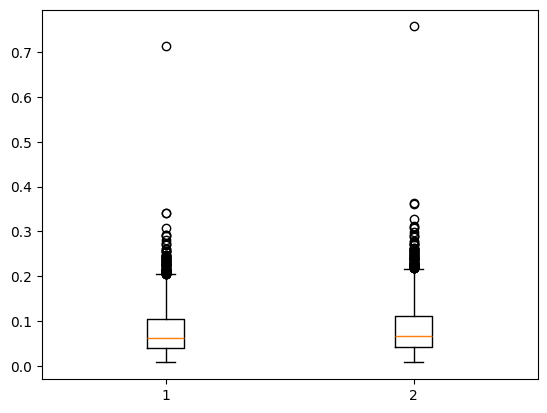

In [75]:
plt.boxplot([all_image_csv['org_recon_mse_normalized'],all_image_csv['range_recon_mse_normalized']])

{'whiskers': [<matplotlib.lines.Line2D at 0x7f400f1deec0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f400f1df400>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f400f1dec20>,
 'medians': [<matplotlib.lines.Line2D at 0x7f400f1df940>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f400f1dfbe0>,
 'means': []}

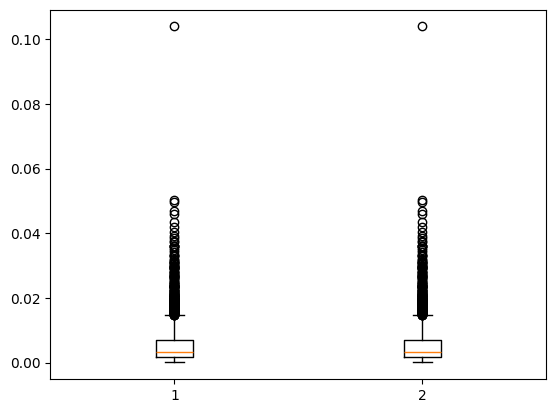

In [72]:
plt.boxplot([all_image_csv['org_recon_mse'],all_image_csv['range_recon_mse']])